## 📈 Store Type Sales Comparison

- **Store Type A** leads in total weekly sales, followed by Type B, with Type C trailing.
- This suggests Type A stores drive the majority of revenue; investigate what makes Type A successful (e.g., location, size, product mix).
- For Type B and C, consider tailored strategies (promotions, layout changes) to boost performance or optimize operations.


## 🔍 Findings: Store Performance Analysis

1. **🏪 Store Type Performance**
   - **Store Type A** recorded the **highest earnings**, followed closely by **Store Type B**.
   - **Store Type C** consistently showed the **lowest weekly sales**, indicating lower revenue potential or smaller market coverage.

2. **📉 Store Characteristics and Sales Trends**
   - **Store Types A and B** experienced a **slight year-over-year decline in sales (~5%)**, despite having a higher number of stores.
   - This may suggest **market saturation** or the need for **strategy optimization** in these store types.

3. **📈 Store Type C Stability**
   - **Store Type C**, while generating lower sales overall, displayed **stable performance** and a **modest annual growth of approximately 3%**.
   - This suggests that **Store Type C may serve a niche market** or benefit from


## Departments with highest sales

/tmp/ipython-input-24-446042402.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipython-input-24-446042402.py:40: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


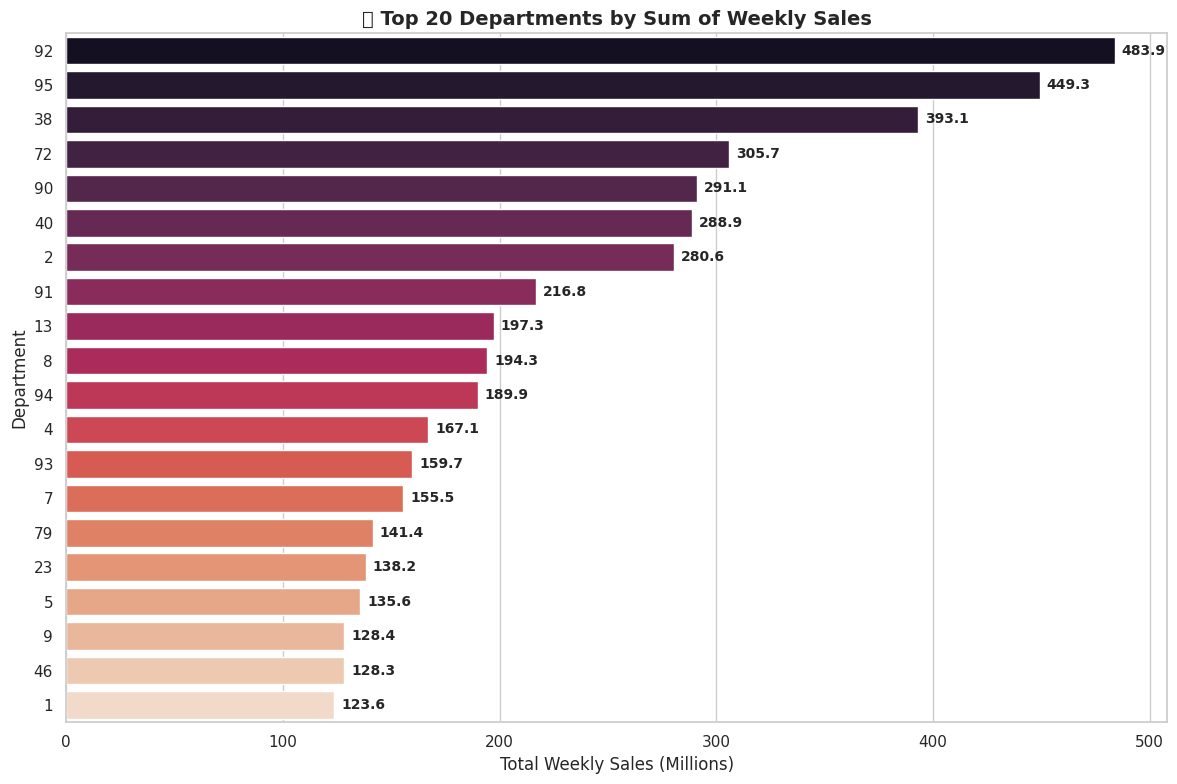

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate total sales per department and convert to millions
dept_sales = df.groupby('Dept', as_index=False)['Weekly_Sales'].sum()
dept_sales['Weekly_Sales_Million'] = dept_sales['Weekly_Sales'] / 1_000_000

# 2. Sort departments by sales descending
dept_sales_sorted = dept_sales.sort_values('Weekly_Sales_Million', ascending=False)

# 3. Choose how many top departments to display (e.g., top 20) for clarity
top_n = 20
top_depts = dept_sales_sorted.head(top_n).copy()

# 4. Set style
sns.set_style('whitegrid')
plt.figure(figsize=(12,8))

# 5. Plot horizontal bar chart for better label readability
ax = sns.barplot(
    y=top_depts['Dept'].astype(str),
    x=top_depts['Weekly_Sales_Million'],
    palette='rocket'
)

# 6. Labels and title
ax.set_xlabel('Total Weekly Sales (Millions)', fontsize=12)
ax.set_ylabel('Department', fontsize=12)
ax.set_title(f'📊 Top {top_n} Departments by Sum of Weekly Sales', fontsize=14, fontweight='bold')

# 7. Annotate values on bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.1f}",
                xy=(width, p.get_y() + p.get_height() / 2),
                xytext=(5, 0),
                textcoords='offset points',
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


## 📈 Top Departments by Total Weekly Sales

- Displaying the top 20 departments by cumulative weekly sales (in millions).
- Departments 38, 92, and 95 (among others in the top list) show the highest sales volumes.
- **Insight:** Focus inventory planning, promotions, and cross-selling strategies on these high-performing departments.  
- For lower-performing departments, analyze whether adjustments in merchandising, pricing, or marketing could boost their performance.

> 💡 **Next Steps:**  
> - Drill down further: analyze monthly or seasonal performance within these top departments.  
> - Investigate if certain store types or regions drive these department sales disproportionately.  
> - Combine with Market Basket Analysis to see what other departments co-occur with these top sellers for cross-sell opportunities.


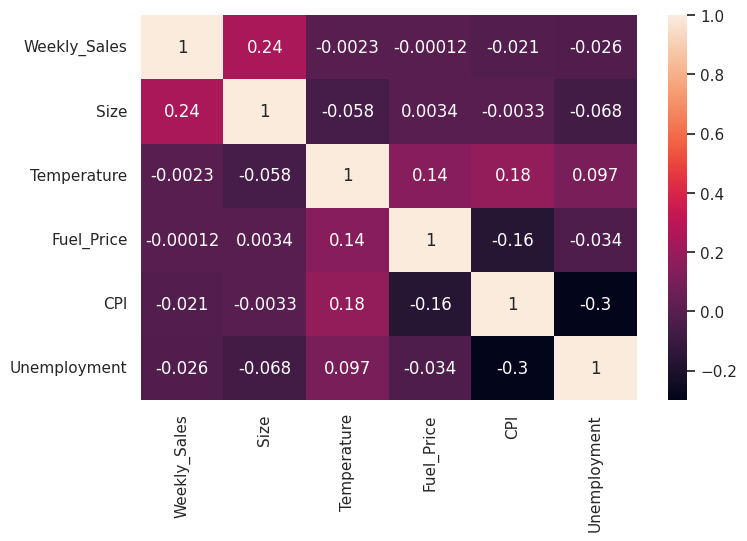

In [25]:
# 5️⃣ EDA & VISUALIZATION
sns.heatmap(df[['Weekly_Sales', 'Size','Temperature','Fuel_Price','CPI','Unemployment']].corr(), annot=True)
plt.show()

## 🧾 Summary Insights

1. **📉 Weak Correlation of Weekly Sales with Other Parameters**  
   - Weekly sales do **not exhibit a strong correlation** with other features such as temperature, fuel price, or CPI.  
   - This indicates that sales performance may be driven more by **seasonality, promotions, or localized factors** than by macroeconomic indicators alone.

2. **📉 CPI vs. Unemployment — Negative Correlation**  
   - There is a **negative correlation between the Consumer Price Index (CPI) and Unemployment**, suggesting that as prices rise (inflation), unemployment tends to fall, which may reflect a growing economy.

3. **🛢️ Fuel Price vs. Unemployment — Negative Correlation**  
   - Similarly, **Fuel Price and Unemployment** also show a **negative correlation**.  
   - This relationship may point toward improved economic activity (higher fuel usage, lower unemployment) during certain periods.

---

> 💡 **Implication:**  
While these correlations offer some macro-level economic insights, **direct relationships with sales are weak**, highlighting the importance of exploring other variables like **markdowns, holidays, store size/type**, and **consumer behavior trends** for accurate forecasting and strategic planning.


# **Data Preprocessing and Feature Engineering:**

Handle missing values, especially in the MarkDown data.

Create new features that could influence sales (e.g., store size/type, regional factors).

## Dataset Inspection

In [26]:
#Merging all the 3 dataset together
sale_store_df = sales.merge(stores, on = 'Store',how='left')
sale_store_df.shape
retail_df = sale_store_df.merge(features, on = ['Store','Date','IsHoliday'],how='left')
retail_df.shape

(421570, 16)

In [27]:
final=retail_df.copy()

In [28]:
#Check for missing values
final.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Type,0
Size,0
Temperature,0
Fuel_Price,0
MarkDown1,270889


In [29]:
#Check for duplicate rows
final.duplicated().sum()

0

In [30]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Type          421570 non-null  object 
 6   Size          421570 non-null  int64  
 7   Temperature   421570 non-null  float64
 8   Fuel_Price    421570 non-null  float64
 9   MarkDown1     150681 non-null  float64
 10  MarkDown2     111248 non-null  float64
 11  MarkDown3     137091 non-null  float64
 12  MarkDown4     134967 non-null  float64
 13  MarkDown5     151432 non-null  float64
 14  CPI           421570 non-null  float64
 15  Unemployment  421570 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [31]:
# Convert dates to datetime objects
final['Date'] = pd.to_datetime(final['Date'],format='%d/%m/%Y')

In [32]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421

In [33]:
final.describe()

,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,136727.915739,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,34875.000000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,93638.000000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,140167.000000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,202505.000000,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000
std,12.785297,30.492054,NaN,22711.183519,60980.583328,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296


In [34]:
final.describe(include=['object'])

,Type
count,421570
unique,3
top,A
freq,215478


### 🛠️ Sales Data Preprocessing & Anomaly Detection Pipeline

This section outlines the complete preprocessing steps for handling and preparing sales data, ensuring optimal performance for anomaly detection models.

#### ✅ Step 1: Handle Missing Values
We impute missing values using the **median** strategy to avoid data skew from extreme outliers.

#### ✅ Step 2: Normalize Sales
We use **Min-Max Scaling** to bring all sales values into the same range, enhancing model training stability.

#### ✅ Step 3: Apply Square Root Transformation
To handle positive skewness in the sales data, we apply a **square root transformation**.

#### ✅ Step 4: Detect Anomalies (Z-score Based)
Anomalies are detected using the Z-score method — any point with a Z-score > |3| is flagged as an outlier.

#### ✅ Step 5: KDE (Violin-style) Plots
KDE plots help visualize the distribution of Markdown variables for additional insights into potential outliers or skewness.

### **KDE plot for MarkDown Features**

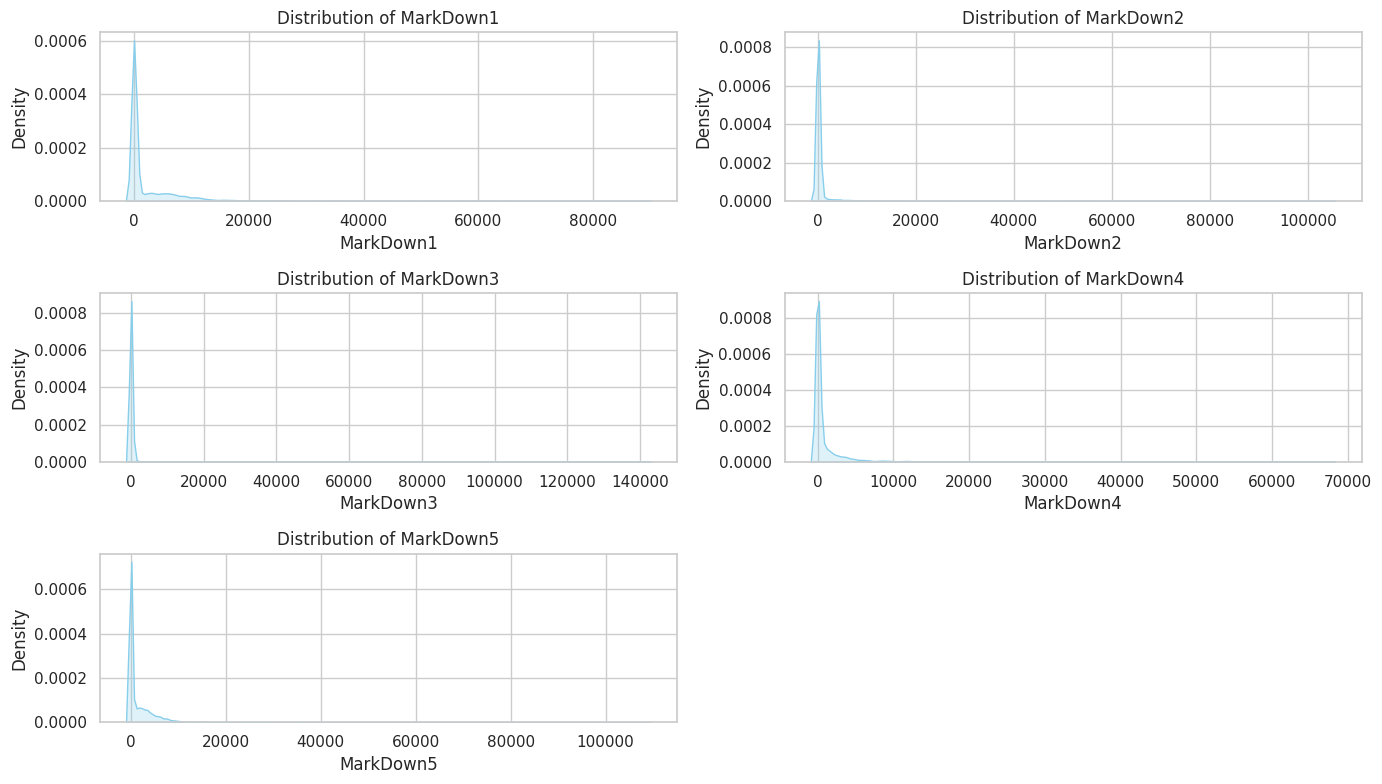

In [35]:
# 📊 Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 🎨 KDE Plotting for MarkDown Features
features = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
num_features = len(features)
num_cols = 2
num_rows = (num_features + 1) // num_cols

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.kdeplot(data=df, x=feature, ax=axes[i], fill=True, color='skyblue')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### **Histogram Visualization for MarkDown Features**

/tmp/ipython-input-36-3029411491.py:31: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


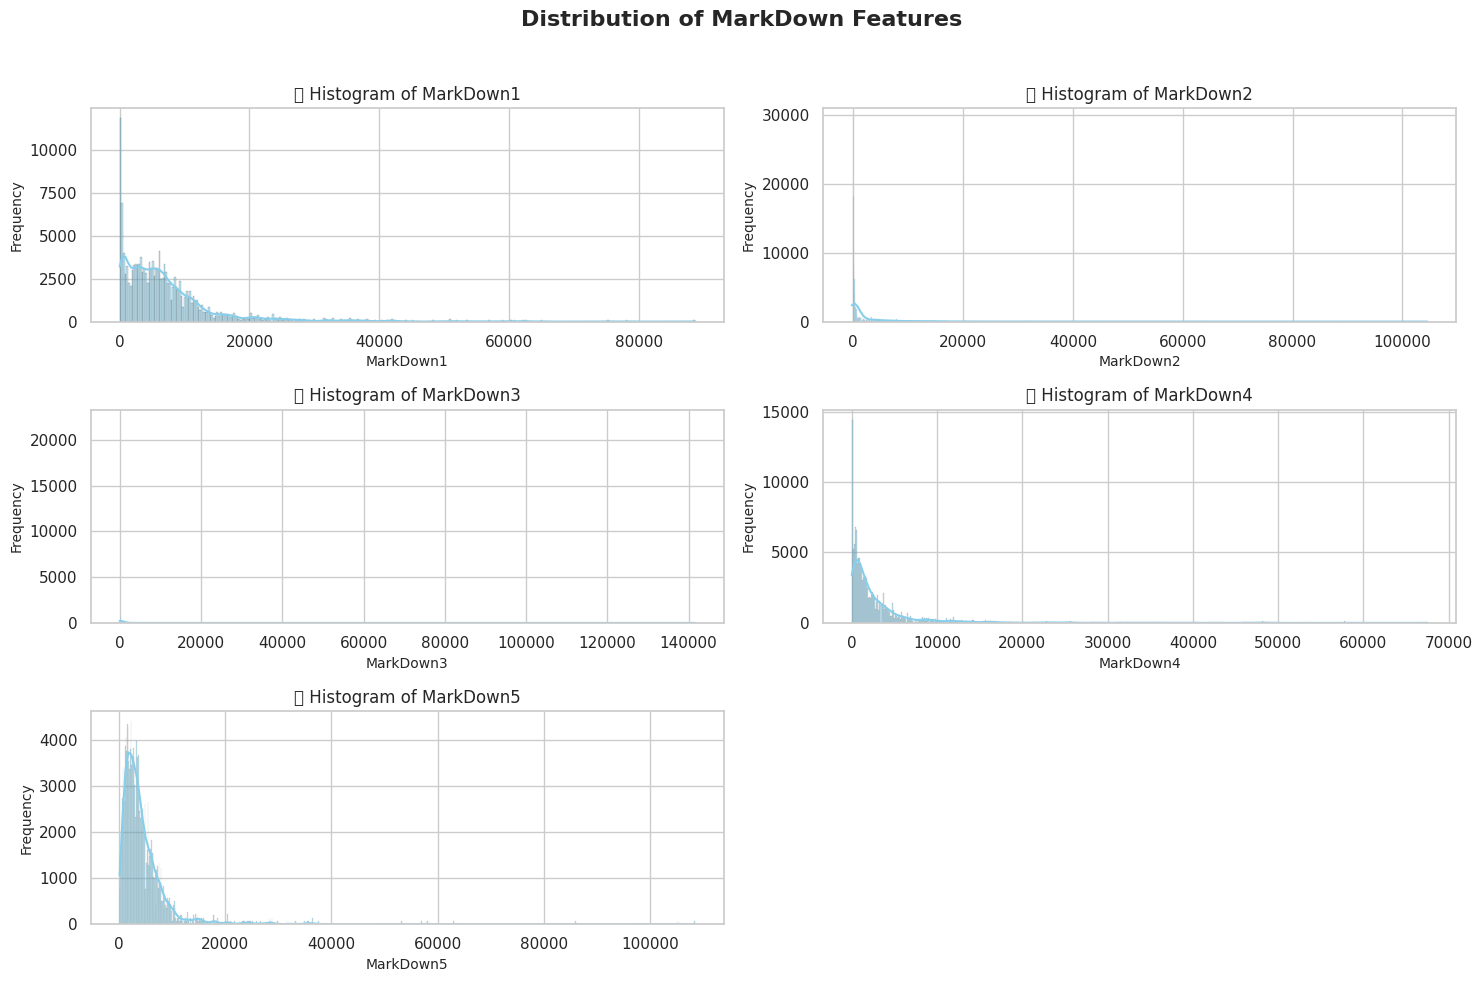

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the features to visualize
features = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Calculate rows and columns for subplots
num_features = len(features)
num_cols = 2
num_rows = (num_features + 1) // num_cols  # ensure enough rows

# Create subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 10))

# Flatten axes array for easy indexing
axes = axes.flatten()

# Plot each feature
for i, feature in enumerate(features):
    sns.histplot(data=final, x=feature, kde=True, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'📊 Histogram of {feature}', fontsize=12)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)

# Remove unused subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Final layout adjustment
plt.suptitle("Distribution of MarkDown Features", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
plt.show()


### **Boxplot Visualization for MarkDown Features**

/tmp/ipython-input-37-3415644130.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final, y=feature, ax=axes[i], palette='pastel')
/tmp/ipython-input-37-3415644130.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final, y=feature, ax=axes[i], palette='pastel')
/tmp/ipython-input-37-3415644130.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final, y=feature, ax=axes[i], palette='pastel')
/tmp/ipython-input-37-3415644130.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

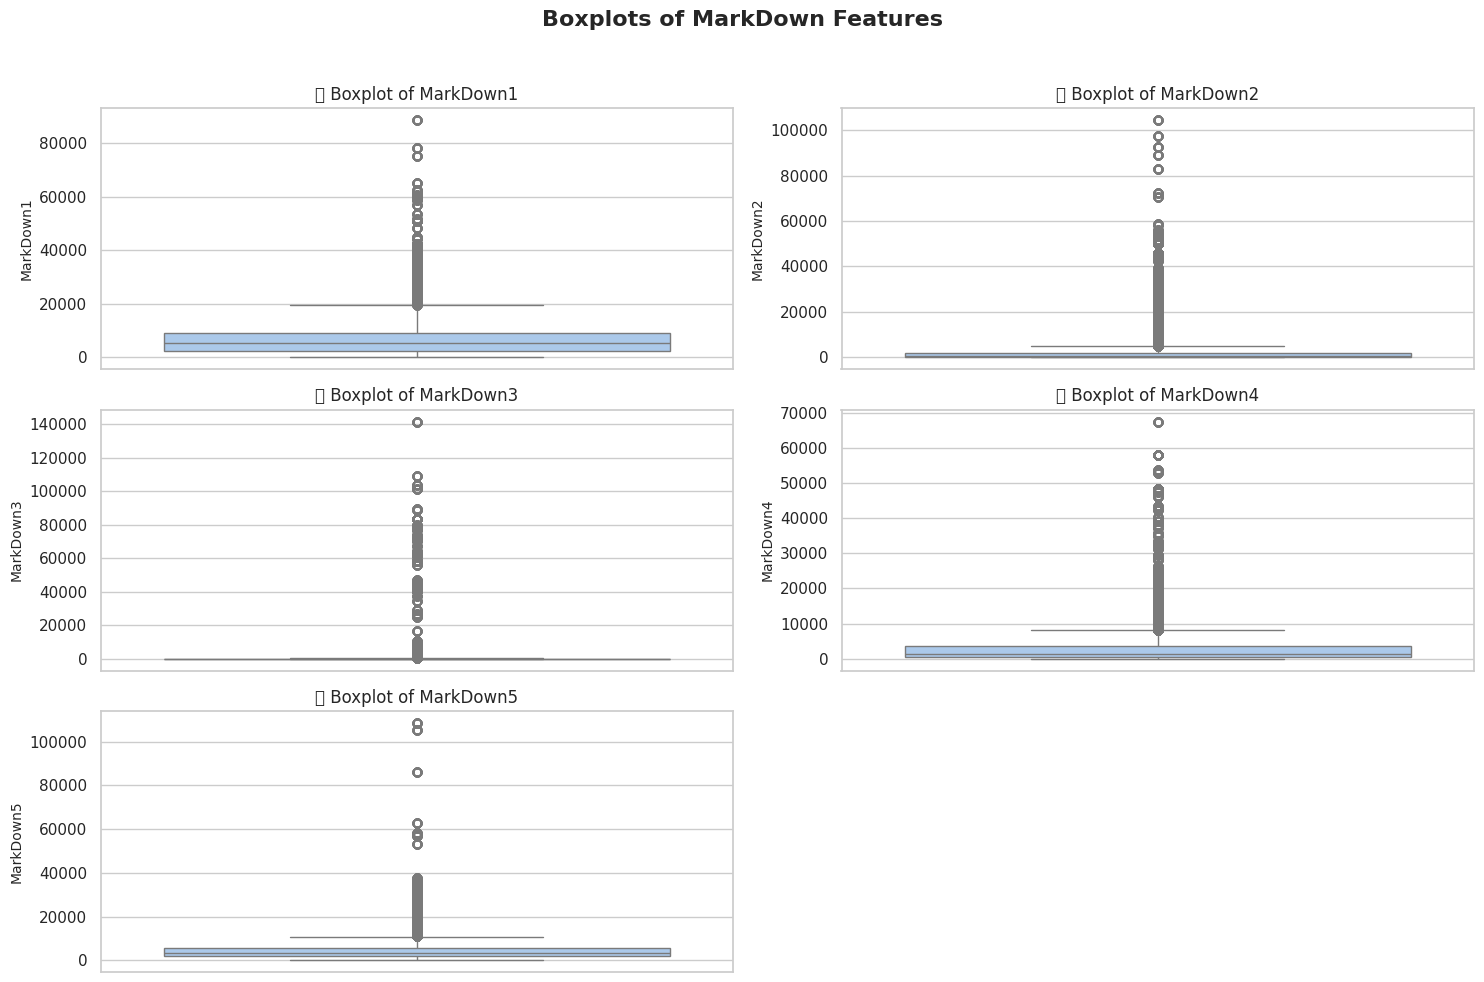

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define MarkDown features
features = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Calculate number of rows and columns
num_cols = 2
num_rows = (len(features) + 1) // num_cols

# Create subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 10))
axes = axes.flatten()

# Create boxplots for each feature
for i, feature in enumerate(features):
    sns.boxplot(data=final, y=feature, ax=axes[i], palette='pastel')
    axes[i].set_title(f'📦 Boxplot of {feature}', fontsize=12)
    axes[i].set_ylabel(feature, fontsize=10)

# Remove empty subplots if features are odd
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Super title and layout
plt.suptitle("Boxplots of MarkDown Features", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### 📊 **Findings:**

- The histogram clearly depicts that the distribution of **MarkDown features** is **right-skewed** and **not normally distributed**.
- The **boxplots** reveal the presence of **outliers** in each of the MarkDown features.
- Approximately **5%–8%** of the total records contain **outlier values**, particularly in the MarkDown-related columns.

---

### 🛠️ **Approach:**

- Removing outliers using **IQR-based thresholds** is **not recommended** in this case, as it could result in the removal of **10% or more** of the dataset, leading to **data loss** and reduced availability for model training.
  
- Instead, we will adopt **robust statistical techniques**, such as:
  - **Median imputation** (rather than mean) for missing values
  - **RobustScaler** (or similar methods) that are less sensitive to outliers during feature scaling

---

### ✅ **Why this approach?**

- **Reduces the impact** of outliers while retaining the majority of the data
- Makes the data distribution more **symmetric**
- Ensures **better model performance** by preserving valuable training data and reducing skew


##**Cleaning the data before anomaly detection and handling.**

### **Step 1️⃣ – Handle Missing Values**

🛠 **Use techniques like median imputation to address missing values in your Markdown data.**

- This step ensures that the dataset is complete and ready for analysis.
- Median imputation is preferred here as it is **robust to outliers** compared to the mean.
- Helps maintain the central tendency of skewed distributions (like the Markdown features).

In [38]:
import pandas as pd

# List of Markdown features
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Fill missing values using median for each column
for col in markdown_cols:
    if col in final.columns:
        final[col].fillna(final[col].median(), inplace=True)

/tmp/ipython-input-38-2129164232.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final[col].fillna(final[col].median(), inplace=True)


### Checking again for null values

In [39]:
final.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Type,0
Size,0
Temperature,0
Fuel_Price,0
MarkDown1,0


###**Visualization of Markdowns after handling missing values**

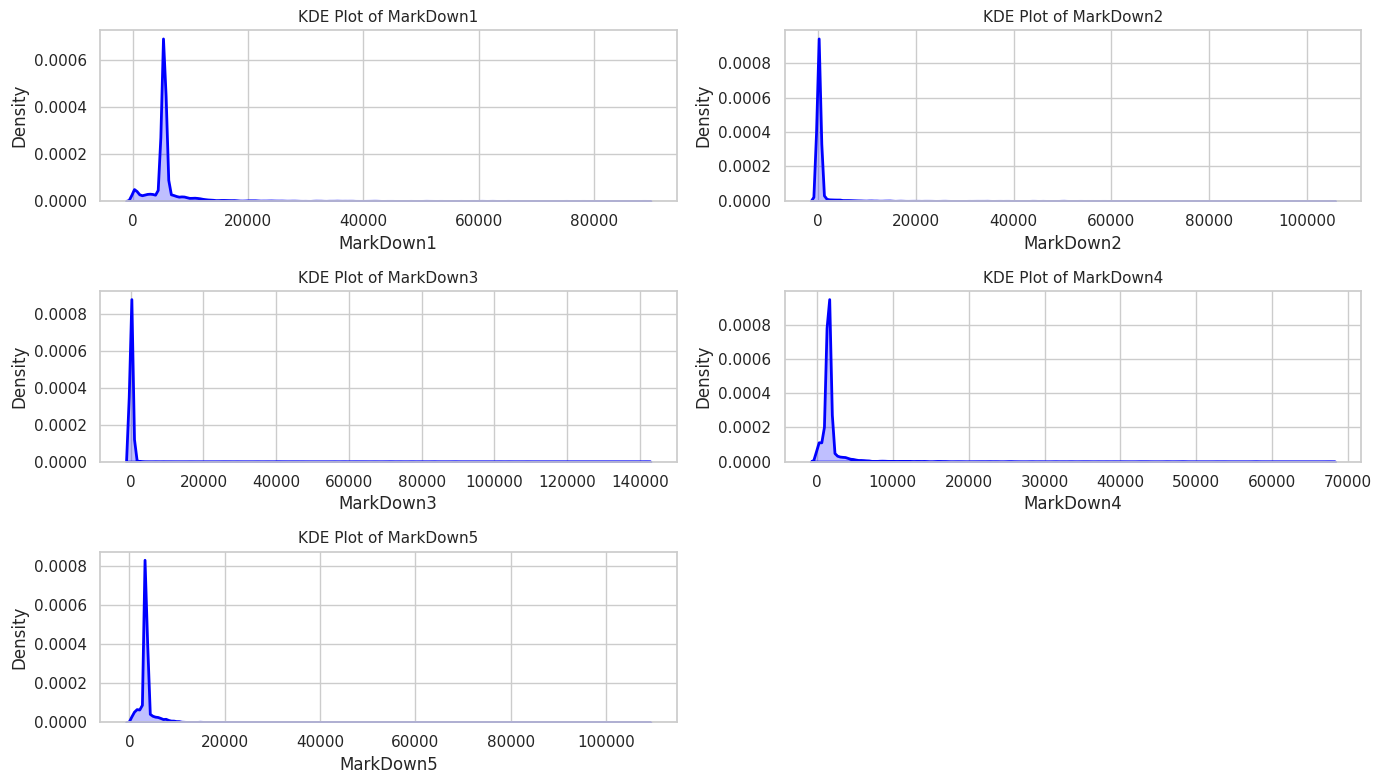

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the features to plot
features = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Calculate grid size
num_features = len(features)
num_cols = 2
num_rows = (num_features + 1) // num_cols

# Create subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(14, 8))
axes = axes.flatten()

# KDE Plot for each feature
for i, feature in enumerate(features):
    sns.kdeplot(data=final, x=feature, ax=axes[i], fill=True, color='blue', linewidth=2)
    axes[i].set_title(f'KDE Plot of {feature}', fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


### ✅ Step 2 – Normalize Sales Data

**Objective:**  
To bring all sales data onto a consistent scale and make it suitable for analysis and machine learning models.

---

**Why Normalize?**  
Normalization is essential when features have different units or magnitudes. It helps in:
- Reducing the impact of outliers  
- Improving convergence in machine learning models  
- Ensuring fair weightage for all variables  

---

**📊 Techniques Used:**

**Standard Scaling (Z-score Normalization):**  
This rescaling method transforms the data so it has a **mean of 0** and **standard deviation of 1**.


In [41]:
# ✅ Step 2: Normalize Sales Data (Min-Max Scaling)

from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Reshape the Weekly_Sales column to 2D and apply scaling
final['Weekly_Sales_normalized'] = scaler.fit_transform(final[['Weekly_Sales']])

# Display basic stats before and after normalization
print("Original Weekly Sales (Min, Max):",
      final['Weekly_Sales'].min(), final['Weekly_Sales'].max())
print("Normalized Weekly Sales (Min, Max):",
      final['Weekly_Sales_normalized'].min(), final['Weekly_Sales_normalized'].max())

Original Weekly Sales (Min, Max): -4988.94 693099.36
Normalized Weekly Sales (Min, Max): 0.0 1.0000000000000002


### ✅ **Step-3: Square Root Transformation to Handle Skewness**

Handling skewed data distributions is critical in many machine learning and statistical applications. Skewed data refers to distributions that are not symmetrical and deviate from a normal (bell-shaped) curve.

When data is right-skewed (i.e., contains a long tail of large values), it can negatively impact model performance and visual analysis. To address this, we apply **data transformation** techniques.

#### 🔹 Why Square Root Transformation?

- Square root transformation is especially useful for **right-skewed** data with **moderate skewness**.
- It **compresses large values** while maintaining the order and structure of data.
- This helps in **reducing skewness** and bringing the distribution closer to normal.

> ⚠️ Note: Unlike log transformation, square root can be applied even when values are zero (but not negative).

#### 💡 Benefits:
- Makes distribution more symmetric.
- Stabilizes variance.
- Improves the performance of models sensitive to data distribution (e.g., linear regression, clustering).

Next, we'll apply a square root transformation to the `Weekly_Sales` column.

In [42]:
final['Sales_sqrt'] = final['Weekly_Sales_normalized'].apply(lambda x: x ** 0.5)

In [43]:
final.head(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Weekly_Sales_normalized,Sales_sqrt
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,5347.45,192.0,24.6,1481.31,3359.45,211.096358,8.106,0.042851,0.207004
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,5347.45,192.0,24.6,1481.31,3359.45,211.242170,8.106,0.073097,0.270365
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,5347.45,192.0,24.6,1481.31,3359.45,211.289143,8.106,0.066732,0.258324
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,5347.45,192.0,24.6,1481.31,3359.45,211.319643,8.106,0.034942,0.186927
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,5347.45,192.0,24.6,1481.31,3359.45,211.350143,8.106,0.038415,0.195997


### **Visualizing the Distribution Before and After Transformation**

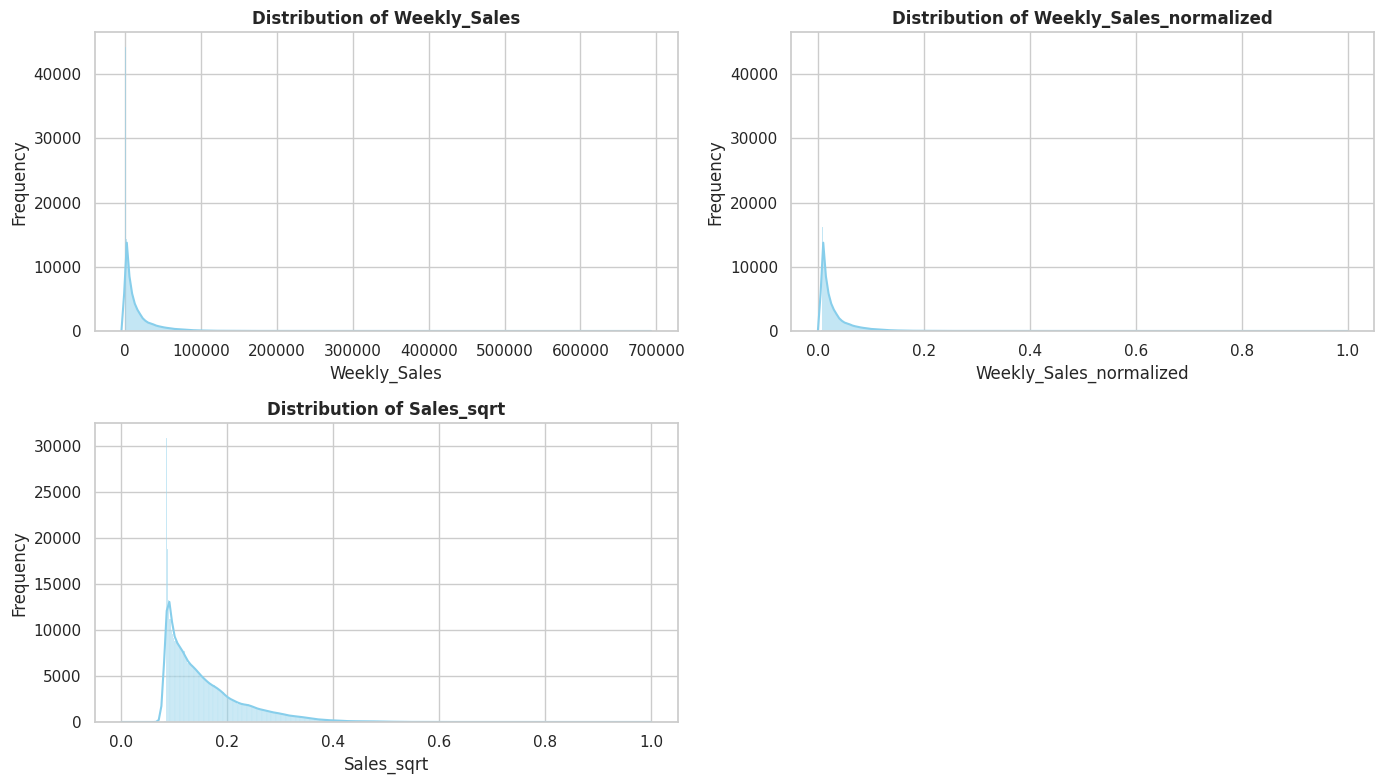

In [44]:
# 🧪 Features to visualize
features = ['Weekly_Sales', 'Weekly_Sales_normalized', 'Sales_sqrt']
num_features = len(features)
num_cols = 2
num_rows = (num_features + 1) // num_cols

# 📊 Set up the subplot layout
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(14, 8))
axes = axes.flatten()

# 📌 Plot histogram with KDE for each feature
for i, feature in enumerate(features):
    sns.histplot(data=final, x=feature, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribution of {feature}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

# Turn off any extra axes if they exist
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


### **Comparison of Weekly Sales Distribution Before and After Square Root Transformation**

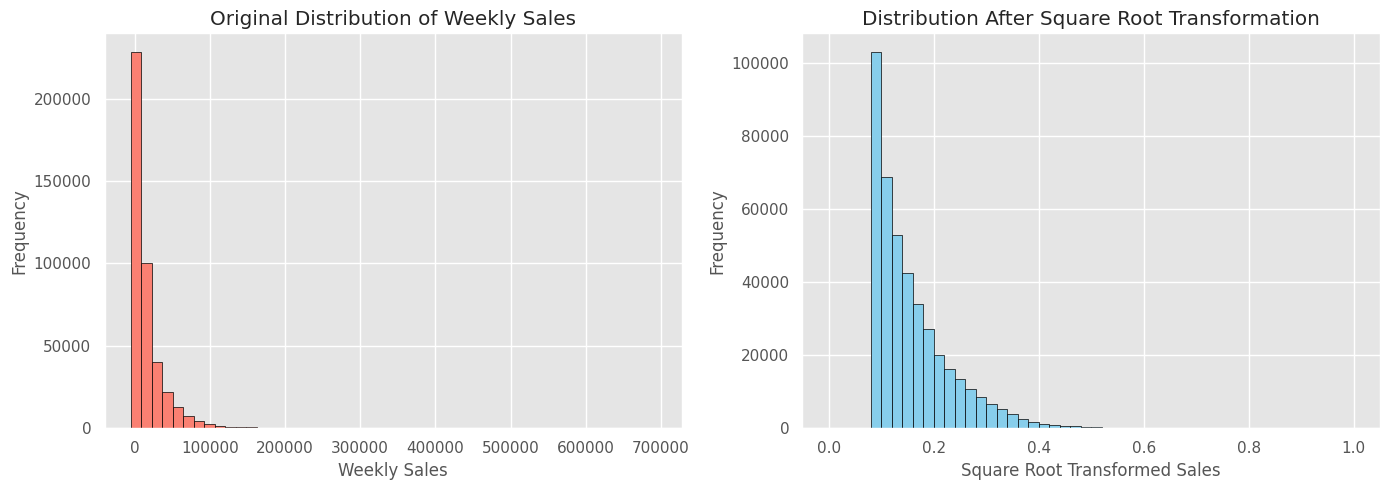

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Set style for better visuals
plt.style.use('ggplot')
plt.figure(figsize=(14, 5))

# 📌 Original Data Distribution
plt.subplot(1, 2, 1)
plt.hist(final['Weekly_Sales'], bins=50, color='salmon', edgecolor='black')
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.title("Original Distribution of Weekly Sales")

# 📌 Transformed Data Distribution (Square Root)
plt.subplot(1, 2, 2)
plt.hist(final['Sales_sqrt'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Square Root Transformed Sales")
plt.ylabel("Frequency")
plt.title("Distribution After Square Root Transformation")

plt.tight_layout()
plt.show()